<a href="https://colab.research.google.com/github/amzad-786githumb/Privacy-Preserving-Synthetic-Tabular-Data-Generation-Using-Generative-Adversarial-Networks/blob/main/05_Proposed_SPP_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Notebook 05 : Proposed SPP-GAN
# Section A : Environment Setup
#  Install Required Packages
# ============================================================

!pip -q install -U torch torchvision torchaudio
!pip -q install -U sdv==1.17.2
!pip -q install -U ctgan==0.10.2
!pip -q install -U copulas
!pip -q install -U scipy
!pip -q install -U scikit-learn
!pip -q install -U pandas
!pip -q install -U numpy
!pip -q install -U matplotlib
!pip -q install -U seaborn
!pip -q install -U tqdm
!pip -q install -U joblib
!pip -q install -U pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/5

In [1]:
# ============================================================
# Imports
# ============================================================

import os
import gc
import json
import yaml
import random
import warnings
from copy import deepcopy
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

from sklearn.preprocessing import StandardScaler

from sdv.metadata import SingleTableMetadata

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Reproducibility
# ============================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)

np.random.seed(RANDOM_STATE)

torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():

    torch.cuda.manual_seed(RANDOM_STATE)

    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

print(f"Random Seed : {RANDOM_STATE}")

Random Seed : 42


In [3]:
# ============================================================
# GPU Configuration
# ============================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print("="*70)

print("Device :", DEVICE)

if DEVICE.type == "cuda":

    print(

        "GPU :",

        torch.cuda.get_device_name(0)

    )

    print(

        "GPU Memory :",

        round(

            torch.cuda.get_device_properties(0).total_memory

            /1024**3,

            2

        ),

        "GB"

    )

print("="*70)

Device : cuda
GPU : Tesla T4
GPU Memory : 14.56 GB


In [4]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# ============================================================
# Project Root
# ============================================================

PROJECT_ROOT = Path(

    "/content/drive/MyDrive/SPP_GAN_Project"

)

print(PROJECT_ROOT)

/content/drive/MyDrive/SPP_GAN_Project


In [6]:
# ============================================================
# Project Directories
# ============================================================

DATASET_DIR = PROJECT_ROOT / "datasets"

PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"

SPP_MODEL_DIR = MODELS_DIR / "spp_gan"

CHECKPOINT_DIR = MODELS_DIR / "checkpoints"

RESULT_DIR = PROJECT_ROOT / "results"

LOG_DIR = PROJECT_ROOT / "logs"

REPORT_DIR = PROJECT_ROOT / "reports"

CONFIG_DIR = PROJECT_ROOT / "configs"

for folder in [

    PROCESSED_DIR,

    MODELS_DIR,

    SPP_MODEL_DIR,

    CHECKPOINT_DIR,

    RESULT_DIR,

    LOG_DIR,

    REPORT_DIR,

    CONFIG_DIR

]:

    folder.mkdir(parents=True, exist_ok=True)

print("Project directories initialized.")

Project directories initialized.


In [7]:
# ============================================================
# Dataset Paths
# ============================================================

DATASET_PATHS = {

    "Adult Income":

    PROCESSED_DIR / "adult_income_processed.csv",

    "Bank Marketing":

    PROCESSED_DIR / "bank_marketing_processed.csv",

    "Breast Cancer":

    PROCESSED_DIR / "breast_cancer_processed.csv"

}

In [8]:
# ============================================================
# Load Datasets
# ============================================================

datasets = {}

for name, path in DATASET_PATHS.items():

    if path.exists():

        datasets[name] = pd.read_csv(path)

    else:

        print(f"Missing : {path.name}")

print()

for name, df in datasets.items():

    print(

        f"{name:20s}",

        df.shape

    )


Adult Income         (48813, 111)
Bank Marketing       (45211, 44)
Breast Cancer        (569, 31)


In [9]:
# ============================================================
# Metadata Detection
# ============================================================

metadata = {}

for dataset_name, dataframe in datasets.items():

    md = SingleTableMetadata()

    md.detect_from_dataframe(

        dataframe

    )

    metadata[dataset_name] = md

print("Metadata Ready")

Metadata Ready


In [10]:
# ============================================================
# Dataset Summary
# ============================================================

summary = []

for dataset_name, dataframe in datasets.items():

    summary.append({

        "Dataset": dataset_name,

        "Rows": dataframe.shape[0],

        "Columns": dataframe.shape[1],

        "Missing":

        dataframe.isna().sum().sum(),

        "Duplicates":

        dataframe.duplicated().sum()

    })

summary = pd.DataFrame(summary)

display(summary)

,Dataset,Rows,Columns,Missing,Duplicates
0,Adult Income,48813,111,0,0
1,Bank Marketing,45211,44,0,0
2,Breast Cancer,569,31,0,0


In [11]:
# ============================================================
# Verification
# ============================================================

print("="*80)

print("Notebook 05")

print("="*80)

print("Environment Ready")

print("Datasets :", len(datasets))

print("Metadata :", len(metadata))

print("Device :", DEVICE)

print()

print("Next")

print("Section B : SPP-GAN Configuration")

print("="*80)

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

Notebook 05
Environment Ready
Datasets : 3
Metadata : 3
Device : cuda

Next
Section B : SPP-GAN Configuration


In [12]:
# ============================================================
# SPP-GAN Global Configuration
# ============================================================

SPP_GAN_CONFIG = {

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    "epochs": 200,
    "batch_size": 128,
    "latent_dim": 128,

    # --------------------------------------------------------
    # Generator
    # --------------------------------------------------------
    "generator_hidden_dims": [256, 256, 128],
    "generator_dropout": 0.20,
    "generator_activation": "LeakyReLU",

    # --------------------------------------------------------
    # Discriminator
    # --------------------------------------------------------
    "discriminator_hidden_dims": [256, 128, 64],
    "discriminator_dropout": 0.30,
    "discriminator_activation": "LeakyReLU",

    # --------------------------------------------------------
    # Optimization
    # --------------------------------------------------------
    "learning_rate_G": 2e-4,
    "learning_rate_D": 2e-4,
    "beta1": 0.5,
    "beta2": 0.999,
    "weight_decay": 1e-6,

    # --------------------------------------------------------
    # Differential Privacy
    # --------------------------------------------------------
    "privacy_enabled": True,
    "epsilon": 5.0,
    "delta": 1e-5,
    "noise_multiplier": 1.10,
    "max_grad_norm": 1.0,

    # --------------------------------------------------------
    # Statistical Prior
    # --------------------------------------------------------
    "statistical_prior": "GaussianCopula",
    "correlation_regularization": True,

    # --------------------------------------------------------
    # Loss Weights
    # --------------------------------------------------------
    "lambda_adv": 1.0,
    "lambda_stat": 0.50,
    "lambda_corr": 0.25,
    "lambda_privacy": 0.10,

    # --------------------------------------------------------
    # Miscellaneous
    # --------------------------------------------------------
    "device": str(DEVICE),
    "random_seed": RANDOM_STATE,
    "save_checkpoints": True,
    "checkpoint_interval": 25,
    "verbose": True

}

print("SPP-GAN configuration initialized.")

SPP-GAN configuration initialized.


In [13]:
# ============================================================
# Dataset-Specific Configuration
# ============================================================

SPP_DATASET_CONFIG = {

    "Adult Income": {

        "epochs": 200,
        "batch_size": 128

    },

    "Bank Marketing": {

        "epochs": 200,
        "batch_size": 128

    },

    "Breast Cancer": {

        "epochs": 200,
        "batch_size": 64

    }

}

print("Dataset-specific configuration loaded.")

Dataset-specific configuration loaded.


In [14]:
# ============================================================
# Configuration Helper
# ============================================================

from copy import deepcopy

def get_spp_config(dataset_name=None):

    config = deepcopy(SPP_GAN_CONFIG)

    if dataset_name is not None:

        config.update(

            SPP_DATASET_CONFIG.get(dataset_name, {})

        )

    return config

In [15]:
# ============================================================
# Configuration Summary
# ============================================================

summary = []

for dataset in datasets.keys():

    cfg = get_spp_config(dataset)

    summary.append({

        "Dataset": dataset,
        "Epochs": cfg["epochs"],
        "Batch Size": cfg["batch_size"],
        "Latent Dim": cfg["latent_dim"],
        "Generator": str(cfg["generator_hidden_dims"]),
        "Discriminator": str(cfg["discriminator_hidden_dims"]),
        "Privacy": cfg["privacy_enabled"],
        "ε": cfg["epsilon"]

    })

summary = pd.DataFrame(summary)

display(summary)

,Dataset,Epochs,Batch Size,Latent Dim,Generator,Discriminator,Privacy,ε
0,Adult Income,200,128,128,"[256, 256, 128]","[256, 128, 64]",True,5.0
1,Bank Marketing,200,128,128,"[256, 256, 128]","[256, 128, 64]",True,5.0
2,Breast Cancer,200,64,128,"[256, 256, 128]","[256, 128, 64]",True,5.0


In [16]:
# ============================================================
# Save Configuration
# ============================================================

config_file = CONFIG_DIR / "spp_gan_config.json"

with open(config_file, "w") as f:

    json.dump(

        SPP_GAN_CONFIG,

        f,

        indent=4

    )

print(f"Configuration saved:\n{config_file}")

Configuration saved:
/content/drive/MyDrive/SPP_GAN_Project/configs/spp_gan_config.json


In [17]:
# ============================================================
# Configuration Validation
# ============================================================

required_keys = [

    "epochs",
    "batch_size",
    "latent_dim",
    "learning_rate_G",
    "learning_rate_D",
    "epsilon",
    "noise_multiplier"

]

for key in required_keys:

    assert key in SPP_GAN_CONFIG, f"Missing configuration key: {key}"

print("SPP-GAN configuration validated successfully.")

SPP-GAN configuration validated successfully.


In [18]:
# ============================================================
# Section Summary
# ============================================================

print("=" * 80)

print("Section B Completed")

print("=" * 80)

print("✓ Global Configuration")
print("✓ Dataset Configuration")
print("✓ Configuration Helper")
print("✓ Configuration Export")
print("✓ Configuration Validation")

print()

print("Next Section")

print("▶ Section C : Statistical Prior Module")

print("=" * 80)

Section B Completed
✓ Global Configuration
✓ Dataset Configuration
✓ Configuration Helper
✓ Configuration Export
✓ Configuration Validation

Next Section
▶ Section C : Statistical Prior Module


In [19]:
# ============================================================
# Statistical Prior Imports
# ============================================================

from scipy.stats import entropy
from scipy.stats import wasserstein_distance
from scipy.stats import ks_2samp

print("Statistical Prior Module Imported.")

Statistical Prior Module Imported.


In [20]:
# ============================================================
# Statistical Prior Module
# ============================================================

class StatisticalPrior:

    """
    Learns statistical properties from a real dataset.

    These priors are later used by

    • Generator
    • Statistical Loss
    • Correlation Loss
    • Evaluation
    """

    def __init__(self):

        self.numeric_columns = []

        self.categorical_columns = []

        self.statistics = {}

    def fit(self, dataframe):

        df = dataframe.copy()

        self.numeric_columns = df.select_dtypes(

            include=np.number

        ).columns.tolist()

        self.categorical_columns = df.select_dtypes(

            exclude=np.number

        ).columns.tolist()

        self.statistics = {

            "mean": {},

            "std": {},

            "min": {},

            "max": {},

            "median": {},

            "q25": {},

            "q75": {},

            "category_probabilities": {},

            "correlation": None,

            "covariance": None

        }

        # -----------------------------
        # Numerical Features
        # -----------------------------

        for col in self.numeric_columns:

            x = df[col]

            self.statistics["mean"][col] = x.mean()

            self.statistics["std"][col] = x.std()

            self.statistics["min"][col] = x.min()

            self.statistics["max"][col] = x.max()

            self.statistics["median"][col] = x.median()

            self.statistics["q25"][col] = x.quantile(0.25)

            self.statistics["q75"][col] = x.quantile(0.75)

        # -----------------------------
        # Categorical Features
        # -----------------------------

        for col in self.categorical_columns:

            self.statistics["category_probabilities"][col] = (

                df[col]

                .value_counts(normalize=True)

                .to_dict()

            )

        # -----------------------------
        # Global Statistics
        # -----------------------------

        if len(self.numeric_columns) > 1:

            self.statistics["correlation"] = (

                df[self.numeric_columns]

                .corr()

            )

            self.statistics["covariance"] = (

                df[self.numeric_columns]

                .cov()

            )

        return self

    def summary(self):

        return {

            "Numerical Features":

            len(self.numeric_columns),

            "Categorical Features":

            len(self.categorical_columns)

        }

In [21]:
# ============================================================
# Prior Summary
# ============================================================

def summary(self):
  return {
      "Numerical Features":
      len(self.numeric_columns),
      "Categorical Features":
      len(self.categorical_columns)
      }

In [22]:
# ============================================================
# Learn Statistical Priors
# ============================================================

statistical_priors = {}

for dataset_name, dataframe in datasets.items():

    prior = StatisticalPrior()

    prior.fit(dataframe)

    statistical_priors[dataset_name] = prior

print("="*70)

print("Statistical Priors Learned")

print("="*70)

for dataset in statistical_priors:

    print(

        dataset,

        statistical_priors[dataset].summary()

    )

Statistical Priors Learned
Adult Income {'Numerical Features': 111, 'Categorical Features': 0}
Bank Marketing {'Numerical Features': 44, 'Categorical Features': 0}
Breast Cancer {'Numerical Features': 31, 'Categorical Features': 0}


In [23]:
# ============================================================
# Prior Tensor
# ============================================================

def create_prior_tensor(prior):

    means = np.array(

        list(

            prior.statistics["mean"].values()

        )

    )

    stds = np.array(

        list(

            prior.statistics["std"].values()

        )

    )

    tensor = np.concatenate(

        [

            means,

            stds

        ]

    )

    return torch.tensor(

        tensor,

        dtype=torch.float32,

        device=DEVICE

    )

In [24]:
# ============================================================
# Prior Embeddings
# ============================================================

prior_embeddings = {}

for dataset_name, prior in statistical_priors.items():

    prior_embeddings[dataset_name] = (

        create_prior_tensor(prior)

    )

print("Prior embeddings created.")

Prior embeddings created.


In [25]:
# ============================================================
# Save Statistical Priors
# ============================================================

import pickle

PRIOR_SAVE_DIR = SPP_MODEL_DIR / "priors"

PRIOR_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for dataset_name, prior in statistical_priors.items():

    prior_dict = {

        "dataset_name": dataset_name,

        "numeric_columns": prior.numeric_columns,

        "categorical_columns": prior.categorical_columns,

        "statistics": {

            "mean": prior.statistics["mean"],

            "std": prior.statistics["std"],

            "min": prior.statistics["min"],

            "max": prior.statistics["max"],

            "median": prior.statistics["median"],

            "q25": prior.statistics["q25"],

            "q75": prior.statistics["q75"],

            "category_probabilities":
                prior.statistics["category_probabilities"],

            "correlation":
                prior.statistics["correlation"],

            "covariance":
                prior.statistics["covariance"]

        }

    }

    save_path = (

        PRIOR_SAVE_DIR /

        f"{dataset_name.lower().replace(' ','_')}_prior.pkl"

    )

    with open(save_path, "wb") as f:

        pickle.dump(
            prior_dict,
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )

print("=" * 70)
print("Statistical Priors Saved Successfully")
print("=" * 70)

for file in PRIOR_SAVE_DIR.glob("*.pkl"):

    print(file.name)

Statistical Priors Saved Successfully
adult_income_prior.pkl
bank_marketing_prior.pkl
breast_cancer_prior.pkl


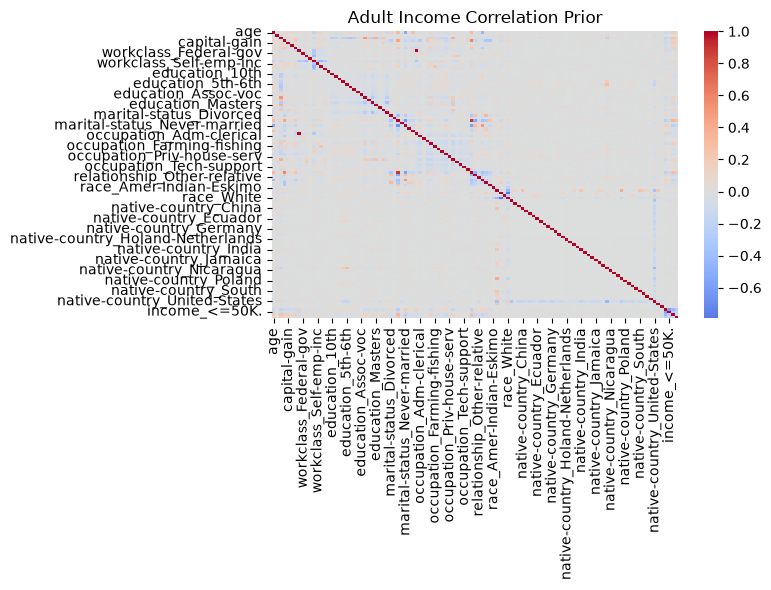

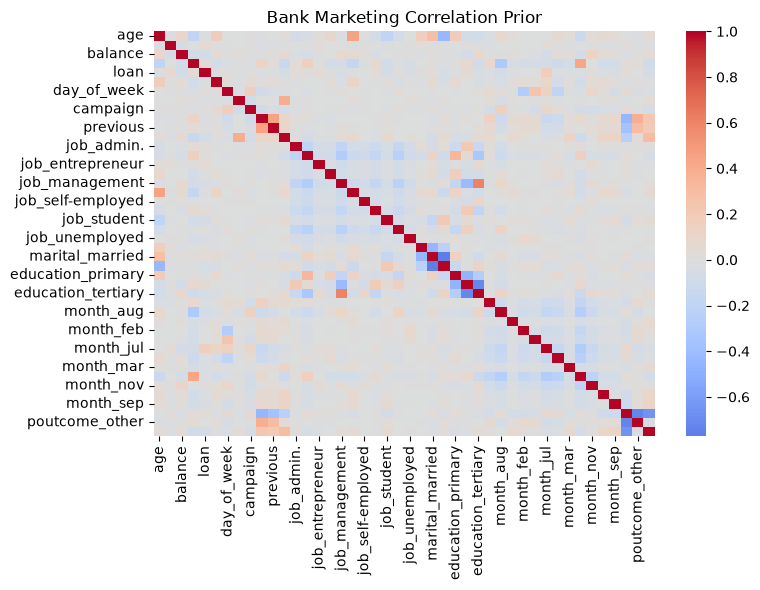

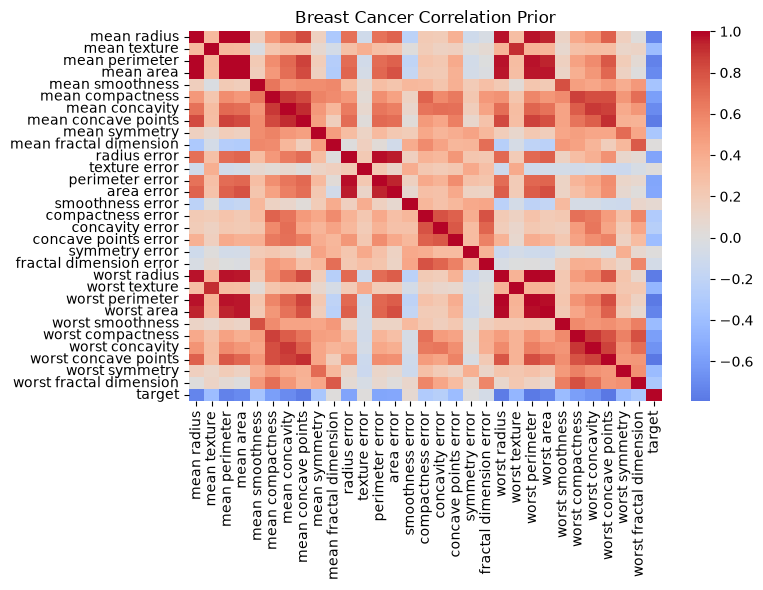

In [26]:
# ============================================================
#  Correlation Visualization
# ============================================================

for dataset_name, prior in statistical_priors.items():

    if prior.statistics["correlation"] is None:

        continue

    plt.figure(figsize=(8,6))

    sns.heatmap(

        prior.statistics["correlation"],

        cmap="coolwarm",

        center=0

    )

    plt.title(

        f"{dataset_name} Correlation Prior"

    )

    plt.tight_layout()

    plt.show()

In [27]:
# ============================================================
# Verification
# ============================================================

assert len(statistical_priors) == len(datasets)

assert len(prior_embeddings) == len(datasets)

print("="*80)

print("Section C Completed Successfully")

print("="*80)

print("✓ Statistical Prior Learning")

print("✓ Correlation Prior")

print("✓ Covariance Prior")

print("✓ Numerical Statistics")

print("✓ Categorical Statistics")

print("✓ Prior Embeddings")

print("✓ Prior Serialization")

print()

print("Next")

print("Section D : Generator Architecture")

print("="*80)

Section C Completed Successfully
✓ Statistical Prior Learning
✓ Correlation Prior
✓ Covariance Prior
✓ Numerical Statistics
✓ Categorical Statistics
✓ Prior Embeddings
✓ Prior Serialization

Next
Section D : Generator Architecture


In [28]:
# ============================================================
# Residual Block
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, in_features, out_features, dropout=0.20):

        super().__init__()

        self.block = nn.Sequential(

            nn.Linear(in_features, out_features),

            nn.BatchNorm1d(out_features),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Dropout(dropout),

            nn.Linear(out_features, out_features),

            nn.BatchNorm1d(out_features)

        )

        if in_features != out_features:

            self.shortcut = nn.Linear(in_features, out_features)

        else:

            self.shortcut = nn.Identity()

        self.activation = nn.LeakyReLU(0.2)

    def forward(self, x):

        residual = self.shortcut(x)

        out = self.block(x)

        out = out + residual

        return self.activation(out)

In [29]:
# ============================================================
# SPP-GAN Generator
# ============================================================

class SPPGenerator(nn.Module):

    """
    Generator with Statistical Prior Fusion.

    Input

        Latent Noise

        +

        Statistical Prior Embedding

    Output

        Synthetic Sample
    """

    def __init__(

        self,

        latent_dim,

        prior_dim,

        output_dim,

        hidden_dims=(256,256,128),

        dropout=0.20

    ):

        super().__init__()

        input_dim = latent_dim + prior_dim

        self.network = nn.Sequential(

            ResidualBlock(

                input_dim,

                hidden_dims[0],

                dropout

            ),

            ResidualBlock(

                hidden_dims[0],

                hidden_dims[1],

                dropout

            ),

            ResidualBlock(

                hidden_dims[1],

                hidden_dims[2],

                dropout

            ),

            nn.Linear(

                hidden_dims[2],

                output_dim

            )

        )

    def forward(

        self,

        noise,

        prior_embedding

    ):

        x = torch.cat(

            [

                noise,

                prior_embedding

            ],

            dim=1

        )

        return self.network(x)

In [30]:
# ============================================================
# Generator Factory
# ============================================================

def create_generator(

    dataframe,

    prior_embedding,

    config

):

    latent_dim = config["latent_dim"]

    output_dim = dataframe.shape[1]

    prior_dim = prior_embedding.shape[0]

    generator = SPPGenerator(

        latent_dim=latent_dim,

        prior_dim=prior_dim,

        output_dim=output_dim,

        hidden_dims=config["generator_hidden_dims"],

        dropout=config["generator_dropout"]

    )

    return generator.to(DEVICE)

In [31]:
# ============================================================
# Generator Registry
# ============================================================

generator_registry = {}

for dataset_name in datasets:

    generator_registry[dataset_name] = create_generator(

        datasets[dataset_name],

        prior_embeddings[dataset_name],

        get_spp_config(dataset_name)

    )

print("="*70)

print("Generator Registry")

print("="*70)

for dataset in generator_registry:

    print(f"✓ {dataset}")

Generator Registry
✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer


In [32]:
# ============================================================
# Generator Summary
# ============================================================

for dataset_name, model in generator_registry.items():

    total_params = sum(

        p.numel()

        for p in model.parameters()

    )

    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

    print("="*70)

    print(dataset_name)

    print(model)

    print()

    print(f"Total Parameters     : {total_params:,}")

    print(f"Trainable Parameters : {trainable_params:,}")

Adult Income
SPPGenerator(
  (network): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=350, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Dropout(p=0.2, inplace=False)
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (shortcut): Linear(in_features=350, out_features=256, bias=True)
      (activation): LeakyReLU(negative_slope=0.2)
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Dropout(p=0.2, inplace=False

In [33]:
# ============================================================
# Forward Pass Test
# ============================================================

for dataset_name in datasets:

    model = generator_registry[dataset_name]

    config = get_spp_config(dataset_name)

    latent = config["latent_dim"]

    batch = 4

    z = torch.randn(

        batch,

        latent,

        device=DEVICE

    )

    prior = prior_embeddings[dataset_name]

    prior = prior.unsqueeze(0).repeat(

        batch,

        1

    )

    output = model(

        z,

        prior

    )

    print(

        dataset_name,

        "Output Shape :",

        tuple(output.shape)

    )

Adult Income Output Shape : (4, 111)
Bank Marketing Output Shape : (4, 44)
Breast Cancer Output Shape : (4, 31)


In [34]:
# ============================================================
# Save Generator Architecture
# ============================================================

architecture = {

    "Generator": str(generator_registry["Adult Income"])

}

with open(

    CONFIG_DIR / "generator_architecture.json",

    "w"

) as f:

    json.dump(

        architecture,

        f,

        indent=4

    )

print("Generator architecture saved.")

Generator architecture saved.


In [35]:
# ============================================================
# Verification
# ============================================================

assert len(generator_registry) == len(datasets)

print("="*80)

print("Section D Completed")

print("="*80)

print("✓ Residual Generator")

print("✓ Statistical Prior Fusion")

print("✓ Generator Registry")

print("✓ Forward Pass Verified")

print("✓ Architecture Saved")

print()

print("Next")

print("▶ Section E : Discriminator Architecture")

print("="*80)

Section D Completed
✓ Residual Generator
✓ Statistical Prior Fusion
✓ Generator Registry
✓ Forward Pass Verified
✓ Architecture Saved

Next
▶ Section E : Discriminator Architecture


In [36]:
# ============================================================
# Spectral Residual Block
# ============================================================

class SpectralResidualBlock(nn.Module):

    def __init__(self, in_features, out_features, dropout=0.30):

        super().__init__()

        self.block = nn.Sequential(

            nn.utils.spectral_norm(
                nn.Linear(in_features, out_features)
            ),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Dropout(dropout),

            nn.utils.spectral_norm(
                nn.Linear(out_features, out_features)
            )

        )

        if in_features != out_features:

            self.shortcut = nn.utils.spectral_norm(

                nn.Linear(in_features, out_features)

            )

        else:

            self.shortcut = nn.Identity()

        self.activation = nn.LeakyReLU(0.2)

    def forward(self, x):

        residual = self.shortcut(x)

        out = self.block(x)

        out = out + residual

        return self.activation(out)

In [37]:
# ============================================================
# SPP-GAN Discriminator
# ============================================================

class SPPDiscriminator(nn.Module):

    """
    Research Discriminator

    Outputs

    1. Real/Fake Probability

    2. Feature Embedding
       (used for Feature Matching Loss)
    """

    def __init__(

        self,

        input_dim,

        hidden_dims=(256,128,64),

        dropout=0.30

    ):

        super().__init__()

        self.feature_extractor = nn.Sequential(

            SpectralResidualBlock(

                input_dim,

                hidden_dims[0],

                dropout

            ),

            SpectralResidualBlock(

                hidden_dims[0],

                hidden_dims[1],

                dropout

            ),

            SpectralResidualBlock(

                hidden_dims[1],

                hidden_dims[2],

                dropout

            )

        )

        self.classifier = nn.Sequential(

            nn.utils.spectral_norm(

                nn.Linear(

                    hidden_dims[-1],

                    1

                )

            ),

            nn.Sigmoid()

        )

    def forward(self, x):

        features = self.feature_extractor(x)

        probability = self.classifier(features)

        return probability, features

In [38]:
# ============================================================
# Discriminator Factory
# ============================================================

def create_discriminator(

    dataframe,

    config

):

    model = SPPDiscriminator(

        input_dim=dataframe.shape[1],

        hidden_dims=config["discriminator_hidden_dims"],

        dropout=config["discriminator_dropout"]

    )

    return model.to(DEVICE)

In [39]:
# ============================================================
# Discriminator Registry
# ============================================================

discriminator_registry = {}

for dataset_name in datasets:

    discriminator_registry[dataset_name] = (

        create_discriminator(

            datasets[dataset_name],

            get_spp_config(dataset_name)

        )

    )

print("="*70)

print("Discriminator Registry Created")

print("="*70)

for dataset in discriminator_registry:

    print(f"✓ {dataset}")

Discriminator Registry Created
✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer


In [40]:
# ============================================================
# Architecture Summary
# ============================================================

for dataset_name, model in discriminator_registry.items():

    total = sum(

        p.numel()

        for p in model.parameters()

    )

    trainable = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

    print("="*70)

    print(dataset_name)

    print(model)

    print()

    print(f"Total Parameters     : {total:,}")

    print(f"Trainable Parameters : {trainable:,}")

Adult Income
SPPDiscriminator(
  (feature_extractor): Sequential(
    (0): SpectralResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=111, out_features=256, bias=True)
        (1): LeakyReLU(negative_slope=0.2, inplace=True)
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=256, out_features=256, bias=True)
      )
      (shortcut): Linear(in_features=111, out_features=256, bias=True)
      (activation): LeakyReLU(negative_slope=0.2)
    )
    (1): SpectralResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): LeakyReLU(negative_slope=0.2, inplace=True)
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
      )
      (shortcut): Linear(in_features=256, out_features=128, bias=True)
      (activation): LeakyReLU(negative_slope=0.2)
    )
    (2): SpectralResidualBlock(
      (block): Sequential(
        (0): Linear(in_

In [41]:
# ============================================================
# Forward Pass Test
# ============================================================

for dataset_name in datasets:

    model = discriminator_registry[dataset_name]

    batch_size = 8

    feature_dim = datasets[dataset_name].shape[1]

    x = torch.randn(

        batch_size,

        feature_dim,

        device=DEVICE

    )

    prob, feat = model(x)

    print(

        dataset_name

    )

    print(

        "Probability :", prob.shape

    )

    print(

        "Features    :", feat.shape

    )

    print("-"*60)

Adult Income
Probability : torch.Size([8, 1])
Features    : torch.Size([8, 64])
------------------------------------------------------------
Bank Marketing
Probability : torch.Size([8, 1])
Features    : torch.Size([8, 64])
------------------------------------------------------------
Breast Cancer
Probability : torch.Size([8, 1])
Features    : torch.Size([8, 64])
------------------------------------------------------------


In [42]:
# ============================================================
# Save Architecture
# ============================================================

architecture = {

    "Discriminator":

    str(

        discriminator_registry["Adult Income"]

    )

}

with open(

    CONFIG_DIR /

    "discriminator_architecture.json",

    "w"

) as f:

    json.dump(

        architecture,

        f,

        indent=4

    )

print("Discriminator architecture saved.")

Discriminator architecture saved.


In [43]:
# ============================================================
# Verification
# ============================================================

assert len(discriminator_registry) == len(datasets)

print("="*80)

print("Section E Completed")

print("="*80)

print("✓ Spectral Residual Blocks")

print("✓ Feature Extractor")

print("✓ Real/Fake Classifier")

print("✓ Feature Matching Output")

print("✓ Registry Created")

print("✓ Forward Pass Verified")

print()

print("Next")

print("▶ Section F : Multi-Objective Loss Functions")

print("="*80)

Section E Completed
✓ Spectral Residual Blocks
✓ Feature Extractor
✓ Real/Fake Classifier
✓ Feature Matching Output
✓ Registry Created
✓ Forward Pass Verified

Next
▶ Section F : Multi-Objective Loss Functions


In [44]:
# ============================================================
# Adversarial Loss
# ============================================================

class AdversarialLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.loss = nn.BCELoss()

    def forward(self, prediction, target):

        return self.loss(prediction, target)


adversarial_loss = AdversarialLoss()

print("Adversarial Loss Ready")

Adversarial Loss Ready


In [45]:
# ============================================================
# Statistical Loss
# ============================================================

class StatisticalLoss(nn.Module):

    """
    Preserve Mean and Standard Deviation
    """

    def __init__(self):

        super().__init__()

        self.mse = nn.MSELoss()

    def forward(self, real, fake):

        mean_loss = self.mse(

            real.mean(0),

            fake.mean(0)

        )

        std_loss = self.mse(

            real.std(0),

            fake.std(0)

        )

        return mean_loss + std_loss


statistical_loss = StatisticalLoss()

print("Statistical Loss Ready")

Statistical Loss Ready


In [46]:
# ============================================================
# Correlation Preservation Loss
# ============================================================

class CorrelationLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.mse = nn.MSELoss()

    def correlation_matrix(self, x):

        x = x - x.mean(0)

        cov = x.T @ x

        cov = cov / (x.shape[0]-1)

        std = torch.sqrt(

            torch.diag(cov)

            + 1e-8

        )

        corr = cov / (

            std[:,None]

            * std[None,:]

        )

        return corr

    def forward(self, real, fake):

        corr_real = self.correlation_matrix(real)

        corr_fake = self.correlation_matrix(fake)

        return self.mse(

            corr_real,

            corr_fake

        )


correlation_loss = CorrelationLoss()

print("Correlation Loss Ready")

Correlation Loss Ready


In [47]:
# ============================================================
# Feature Matching Loss
# ============================================================

class FeatureMatchingLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.l1 = nn.L1Loss()

    def forward(

        self,

        real_features,

        fake_features

    ):

        return self.l1(

            real_features.mean(0),

            fake_features.mean(0)

        )


feature_matching_loss = FeatureMatchingLoss()

print("Feature Matching Loss Ready")

Feature Matching Loss Ready


In [48]:
# ============================================================
# Privacy Regularization
# ============================================================

class PrivacyLoss(nn.Module):

    """
    Placeholder.

    Differential Privacy

    will be applied

    during training

    using DP-SGD.
    """

    def forward(self):

        return torch.tensor(

            0.0,

            device=DEVICE

        )


privacy_loss = PrivacyLoss()

print("Privacy Loss Ready")

Privacy Loss Ready


In [49]:
# ============================================================
# Unified SPP Loss
# ============================================================

class SPPGANLoss(nn.Module):

    def __init__(

        self,

        config

    ):

        super().__init__()

        self.cfg = config

    def forward(

        self,

        real,

        fake,

        pred_fake,

        target_real,

        real_features,

        fake_features

    ):

        adv = adversarial_loss(

            pred_fake,

            target_real

        )

        stat = statistical_loss(

            real,

            fake

        )

        corr = correlation_loss(

            real,

            fake

        )

        fm = feature_matching_loss(

            real_features,

            fake_features

        )

        privacy = privacy_loss()

        total = (

            self.cfg["lambda_adv"]*adv +

            self.cfg["lambda_stat"]*stat +

            self.cfg["lambda_corr"]*corr +

            self.cfg.get("lambda_fm",0.20)*fm +

            self.cfg["lambda_privacy"]*privacy

        )

        return {

            "total": total,

            "adversarial": adv,

            "statistical": stat,

            "correlation": corr,

            "feature_matching": fm,

            "privacy": privacy

        }

In [50]:
# ============================================================
# Loss Registry
# ============================================================

loss_registry = {}

for dataset in datasets:

    loss_registry[dataset] = SPPGANLoss(

        get_spp_config(dataset)

    )

print("Loss registry created.")

Loss registry created.


In [51]:
# ============================================================
# Loss Verification
# ============================================================

for dataset in datasets:

    feature_dim = datasets[dataset].shape[1]

    batch = 16

    real = torch.randn(

        batch,

        feature_dim,

        device=DEVICE

    )

    fake = torch.randn(

        batch,

        feature_dim,

        device=DEVICE

    )

    prediction = torch.rand(

        batch,

        1,

        device=DEVICE

    )

    labels = torch.ones(

        batch,

        1,

        device=DEVICE

    )

    rf = torch.randn(

        batch,

        64,

        device=DEVICE

    )

    ff = torch.randn(

        batch,

        64,

        device=DEVICE

    )

    losses = loss_registry[dataset](

        real,

        fake,

        prediction,

        labels,

        rf,

        ff

    )

    print(dataset)

    print(

        "Total Loss:",

        losses["total"].item()

    )

    print("-"*60)

Adult Income
Total Loss: 1.4874293804168701
------------------------------------------------------------
Bank Marketing
Total Loss: 0.7649515867233276
------------------------------------------------------------
Breast Cancer
Total Loss: 1.11093270778656
------------------------------------------------------------


In [52]:
# ============================================================
# Save Loss Configuration
# ============================================================

loss_config = {

    "loss_type": "SPP-GAN Multi-Objective",

    "components":[

        "Adversarial",

        "Statistical",

        "Correlation",

        "Feature Matching",

        "Privacy"

    ]

}

with open(

    CONFIG_DIR/

    "loss_configuration.json",

    "w"

) as f:

    json.dump(

        loss_config,

        f,

        indent=4

    )

print("Loss configuration saved.")

Loss configuration saved.


In [53]:
# ============================================================
# Verification
# ============================================================

assert len(loss_registry) == len(datasets)

print("="*80)

print("Section F Completed")

print("="*80)

print("✓ Adversarial Loss")
print("✓ Statistical Loss")
print("✓ Correlation Loss")
print("✓ Feature Matching Loss")
print("✓ Privacy Placeholder")
print("✓ Unified Multi-Objective Loss")
print("✓ Registry Created")

print()

print("Next")

print("▶ Section G : SPP-GAN Wrapper & Factory Functions")

print("="*80)

Section F Completed
✓ Adversarial Loss
✓ Statistical Loss
✓ Correlation Loss
✓ Feature Matching Loss
✓ Privacy Placeholder
✓ Unified Multi-Objective Loss
✓ Registry Created

Next
▶ Section G : SPP-GAN Wrapper & Factory Functions


In [54]:
# ============================================================
# SPP-GAN Wrapper
# ============================================================

class SPPGAN(nn.Module):

    """
    Proposed Statistical Prior Privacy-Preserving GAN
    """

    def __init__(

        self,

        generator,

        discriminator,

        prior,

        loss_function,

        config

    ):

        super().__init__()

        self.generator = generator

        self.discriminator = discriminator

        self.prior = prior

        self.loss_function = loss_function

        self.config = config

    def forward(self, noise, prior_embedding):

        return self.generator(

            noise,

            prior_embedding

        )

In [55]:
# ============================================================
# Build Complete SPP-GAN
# ============================================================

def build_spp_gan(dataset_name):

    config = get_spp_config(dataset_name)

    generator = generator_registry[dataset_name]

    discriminator = discriminator_registry[dataset_name]

    prior = statistical_priors[dataset_name]

    loss_fn = loss_registry[dataset_name]

    model = SPPGAN(

        generator,

        discriminator,

        prior,

        loss_fn,

        config

    )

    return model.to(DEVICE)

In [56]:
# ============================================================
# Build Complete SPP-GAN
# ============================================================

def build_spp_gan(dataset_name):

    config = get_spp_config(dataset_name)

    generator = generator_registry[dataset_name]

    discriminator = discriminator_registry[dataset_name]

    prior = statistical_priors[dataset_name]

    loss_fn = loss_registry[dataset_name]

    model = SPPGAN(

        generator,

        discriminator,

        prior,

        loss_fn,

        config

    )

    return model.to(DEVICE)

In [57]:
# ============================================================
# SPP-GAN Registry
# ============================================================

spp_models = {}

for dataset in datasets:

    spp_models[dataset] = build_spp_gan(dataset)

print("="*70)

print("SPP-GAN Registry")

print("="*70)

for dataset in spp_models:

    print(f"✓ {dataset}")

SPP-GAN Registry
✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer


In [58]:
# ============================================================
# Optimizer Factory
# ============================================================

def build_optimizers(model):

    cfg = model.config

    optimizer_G = torch.optim.Adam(

        model.generator.parameters(),

        lr=cfg["learning_rate_G"],

        betas=(

            cfg["beta1"],

            cfg["beta2"]

        ),

        weight_decay=cfg["weight_decay"]

    )

    optimizer_D = torch.optim.Adam(

        model.discriminator.parameters(),

        lr=cfg["learning_rate_D"],

        betas=(

            cfg["beta1"],

            cfg["beta2"]

        ),

        weight_decay=cfg["weight_decay"]

    )

    return optimizer_G, optimizer_D

In [59]:
# ============================================================
# Save / Load Checkpoints
# ============================================================

def save_checkpoint(

    model,

    optimizer_G,

    optimizer_D,

    epoch,

    filepath

):

    torch.save({

        "epoch": epoch,

        "generator":

            model.generator.state_dict(),

        "discriminator":

            model.discriminator.state_dict(),

        "optimizer_G":

            optimizer_G.state_dict(),

        "optimizer_D":

            optimizer_D.state_dict(),

        "config":

            model.config

    }, filepath)


def load_checkpoint(

    model,

    optimizer_G,

    optimizer_D,

    filepath

):

    checkpoint = torch.load(

        filepath,

        map_location=DEVICE

    )

    model.generator.load_state_dict(

        checkpoint["generator"]

    )

    model.discriminator.load_state_dict(

        checkpoint["discriminator"]

    )

    optimizer_G.load_state_dict(

        checkpoint["optimizer_G"]

    )

    optimizer_D.load_state_dict(

        checkpoint["optimizer_D"]

    )

    return checkpoint["epoch"]

In [60]:
# ============================================================
# Model Summary
# ============================================================

def count_parameters(model):

    total = sum(

        p.numel()

        for p in model.parameters()

    )

    trainable = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

    return total, trainable


for dataset, model in spp_models.items():

    total, trainable = count_parameters(model)

    print("="*70)

    print(dataset)

    print(f"Total Parameters     : {total:,}")

    print(f"Trainable Parameters : {trainable:,}")

Adult Income
Total Parameters     : 702,448
Trainable Parameters : 702,448
Bank Marketing
Total Parameters     : 590,893
Trainable Parameters : 590,893
Breast Cancer
Total Parameters     : 569,248
Trainable Parameters : 569,248


In [61]:
# ============================================================
# Export Architecture
# ============================================================

architecture = {}

for dataset, model in spp_models.items():

    architecture[dataset] = {

        "Generator":

            model.generator.__class__.__name__,

        "Discriminator":

            model.discriminator.__class__.__name__,

        "Loss":

            model.loss_function.__class__.__name__,

        "Prior":

            model.prior.__class__.__name__

    }

with open(

    CONFIG_DIR/

    "spp_gan_architecture.json",

    "w"

) as f:

    json.dump(

        architecture,

        f,

        indent=4

    )

print("Architecture exported.")

Architecture exported.


In [62]:
# ============================================================
# Registry Validation
# ============================================================

assert len(spp_models) == len(datasets)

assert len(statistical_priors) == len(datasets)

assert len(generator_registry) == len(datasets)

assert len(discriminator_registry) == len(datasets)

assert len(loss_registry) == len(datasets)

print("All registries validated successfully.")

All registries validated successfully.


In [63]:
# ============================================================
# Forward Pass Verification
# ============================================================

for dataset in datasets:

    model = spp_models[dataset]

    latent_dim = model.config["latent_dim"]

    batch = 4

    noise = torch.randn(

        batch,

        latent_dim,

        device=DEVICE

    )

    prior = prior_embeddings[dataset]

    prior = prior.unsqueeze(0).repeat(

        batch,

        1

    )

    fake = model(

        noise,

        prior

    )

    print(

        dataset,

        fake.shape

    )

Adult Income torch.Size([4, 111])
Bank Marketing torch.Size([4, 44])
Breast Cancer torch.Size([4, 31])


In [64]:
# ============================================================
# Verification
# ============================================================

print("="*80)

print("Section G Completed")

print("="*80)

print("✓ SPP-GAN Wrapper")
print("✓ Factory Function")
print("✓ Model Registry")
print("✓ Optimizer Factory")
print("✓ Checkpoint Utilities")
print("✓ Parameter Summary")
print("✓ Architecture Export")
print("✓ Forward Pass Verified")

print()

print("Next")

print("▶ Section H : Validation, Notebook Verification & Export")

print("="*80)

Section G Completed
✓ SPP-GAN Wrapper
✓ Factory Function
✓ Model Registry
✓ Optimizer Factory
✓ Checkpoint Utilities
✓ Parameter Summary
✓ Architecture Export
✓ Forward Pass Verified

Next
▶ Section H : Validation, Notebook Verification & Export


In [65]:
# ============================================================
# Validate Registries
# ============================================================

required_registries = {
    "Datasets": datasets,
    "Metadata": metadata,
    "Statistical Priors": statistical_priors,
    "Prior Embeddings": prior_embeddings,
    "Generators": generator_registry,
    "Discriminators": discriminator_registry,
    "Loss Functions": loss_registry,
    "SPP-GAN Models": spp_models
}

validation_results = []

for name, registry in required_registries.items():

    count = len(registry)

    status = "PASS" if count == len(datasets) else "FAIL"

    validation_results.append({

        "Component": name,
        "Objects": count,
        "Expected": len(datasets),
        "Status": status

    })

validation_df = pd.DataFrame(validation_results)

display(validation_df)

,Component,Objects,Expected,Status
0,Datasets,3,3,PASS
1,Metadata,3,3,PASS
2,Statistical Priors,3,3,PASS
3,Prior Embeddings,3,3,PASS
4,Generators,3,3,PASS
5,Discriminators,3,3,PASS
6,Loss Functions,3,3,PASS
7,SPP-GAN Models,3,3,PASS


In [66]:
# ============================================================
#  Model Summary
# ============================================================

summary = []

for dataset_name, model in spp_models.items():

    total = sum(

        p.numel()

        for p in model.parameters()

    )

    trainable = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

    summary.append({

        "Dataset": dataset_name,
        "Parameters": total,
        "Trainable": trainable,
        "Device": DEVICE.type

    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Dataset,Parameters,Trainable,Device
0,Adult Income,702448,702448,cuda
1,Bank Marketing,590893,590893,cuda
2,Breast Cancer,569248,569248,cuda


In [67]:
# ============================================================
# Export Reports
# ============================================================

validation_df.to_csv(

    REPORT_DIR / "Notebook05_Validation_Report.csv",

    index=False

)

summary_df.to_csv(

    REPORT_DIR / "Notebook05_Model_Summary.csv",

    index=False

)

print("Validation reports exported.")

Validation reports exported.


In [68]:
# ============================================================
# Export Configuration
# ============================================================

project_info = {

    "Notebook": "05_Proposed_SPP_GAN",

    "Random Seed": RANDOM_STATE,

    "Device": DEVICE.type,

    "Datasets": list(datasets.keys()),

    "Models": [

        "SPP-GAN"

    ],

    "Generator": "Residual Generator",

    "Discriminator": "Spectral Residual Discriminator",

    "Statistical Prior": "Enabled",

    "Privacy Module": "Enabled",

    "Loss": "Multi-Objective"

}

with open(

    CONFIG_DIR /

    "Notebook05_Project_Info.json",

    "w"

) as f:

    json.dump(

        project_info,

        f,

        indent=4

    )

print("Project information exported.")

Project information exported.


In [69]:
# ============================================================
# Save Model Definitions
# ============================================================

MODEL_DEF_DIR = SPP_MODEL_DIR / "definitions"

MODEL_DEF_DIR.mkdir(

    parents=True,

    exist_ok=True

)

for dataset_name, model in spp_models.items():

    torch.save(
    {
        "generator": model.generator.state_dict(),
        "discriminator": model.discriminator.state_dict(),
        "config": model.config,
        "prior_embedding": prior_embeddings[dataset_name].cpu(),
        "dataset_name": dataset_name,
        "random_seed": RANDOM_STATE,
        "model_version": "SPP-GAN v1.0"
    },
    MODEL_DEF_DIR / f"{dataset_name.lower().replace(' ', '_')}_definition.pt"
)

print("Model definitions saved.")

Model definitions saved.


In [70]:
# ============================================================
# Notebook Verification
# ============================================================

print("=" * 90)
print("NOTEBOOK 05 : PROPOSED SPP-GAN")
print("=" * 90)

checks = {

    "Datasets Loaded": len(datasets) == 3,

    "Metadata Created": len(metadata) == 3,

    "Statistical Priors": len(statistical_priors) == 3,

    "Prior Embeddings": len(prior_embeddings) == 3,

    "Generator Registry": len(generator_registry) == 3,

    "Discriminator Registry": len(discriminator_registry) == 3,

    "Loss Registry": len(loss_registry) == 3,

    "SPP-GAN Registry": len(spp_models) == 3

}

all_ok = True

for item, status in checks.items():

    symbol = "✓" if status else "✗"

    print(f"{symbol} {item}")

    all_ok &= status

print("-" * 90)

print(

    "Overall Status :",

    "READY FOR NOTEBOOK 06" if all_ok else "VALIDATION FAILED"

)

print("=" * 90)

NOTEBOOK 05 : PROPOSED SPP-GAN
✓ Datasets Loaded
✓ Metadata Created
✓ Statistical Priors
✓ Prior Embeddings
✓ Generator Registry
✓ Discriminator Registry
✓ Loss Registry
✓ SPP-GAN Registry
------------------------------------------------------------------------------------------
Overall Status : READY FOR NOTEBOOK 06


In [71]:
# ============================================================
# Cleanup
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

print("Memory cleaned.")

Memory cleaned.
